In [4]:

import sys, importlib.metadata as md, platform
print("Python      :", sys.version.split()[0], "on", platform.system())
print("TensorFlow  :", md.version("tensorflow"))
print("NumPy       :", md.version("numpy"))
print("Pandas      :", md.version("pandas"))


Python      : 3.11.12 on Linux
TensorFlow  : 2.18.0
NumPy       : 2.0.2
Pandas      : 2.2.2


In [5]:

import pandas as pd

# 直接從 Colab 左側檔案讀取 CSV
df = pd.read_csv('/content/IMDB Dataset.csv')

# 查看 DataFrame 資訊
print("DataFrame shape:", df.shape)
df.head()


DataFrame shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:

import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 讀取 CSV
df = pd.read_csv("/content/IMDB Dataset.csv")
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# 分割資料集
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

# 特徵與標籤
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# 文字向量化
max_words = 20000
max_len = 200
tok = Tokenizer(num_words=max_words, oov_token="__OOV__")
tok.fit_on_texts(train_df['review'])

X_train = pad_sequences(tok.texts_to_sequences(train_df['review']), maxlen=max_len)
X_val   = pad_sequences(tok.texts_to_sequences(val_df['review']),   maxlen=max_len)
X_test  = pad_sequences(tok.texts_to_sequences(test_df['review']),  maxlen=max_len)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.regularizers import l2

rnn_model = Sequential([
    Embedding(max_words, 128),
    SimpleRNN(64, kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_rnn = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=128
)


Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 149ms/step - accuracy: 0.6499 - loss: 0.6108 - val_accuracy: 0.7530 - val_loss: 0.5816
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 157ms/step - accuracy: 0.8542 - loss: 0.3833 - val_accuracy: 0.8576 - val_loss: 0.3634
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.9001 - loss: 0.2836 - val_accuracy: 0.8378 - val_loss: 0.3899
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.9269 - loss: 0.2175 - val_accuracy: 0.8550 - val_loss: 0.4156
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 141ms/step - accuracy: 0.9703 - loss: 0.1056 - val_accuracy: 0.8576 - val_loss: 0.4922
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 146ms/step - accuracy: 0.9707 - loss: 0.1040 - val_accuracy: 0.8308 - val_loss: 0.5888


In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(max_words, 128),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3, kernel_regularizer=l2(1e-4)),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=128
)


Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 474s 1s/step - accuracy: 0.6920 - loss: 0.5860 - val_accuracy: 0.8552 - val_loss: 0.3680
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 516s 2s/step - accuracy: 0.8644 - loss: 0.3531 - val_accuracy: 0.8618 - val_loss: 0.3366
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.8864 - loss: 0.3095 - val_accuracy: 0.8658 - val_loss: 0.3405
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.9067 - loss: 0.2599 - val_accuracy: 0.8554 - val_loss: 0.3625
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 506s 2s/step - accuracy: 0.9173 - loss: 0.2376 - val_accuracy: 0.8770 - val_loss: 0.3352
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 492s 1s/step - accuracy: 0.9372 - loss: 0.1906 - val_accuracy: 0.8672 - val_loss: 0.3711


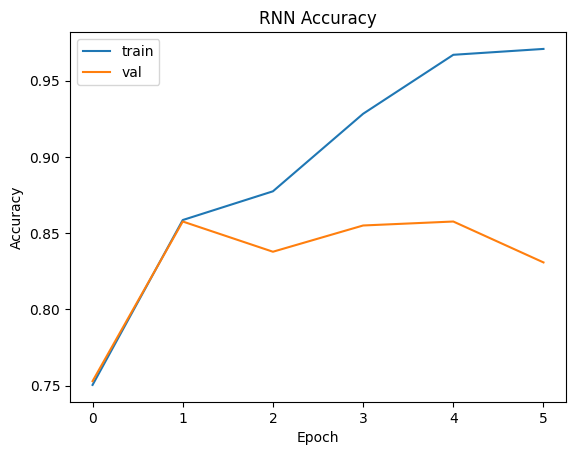

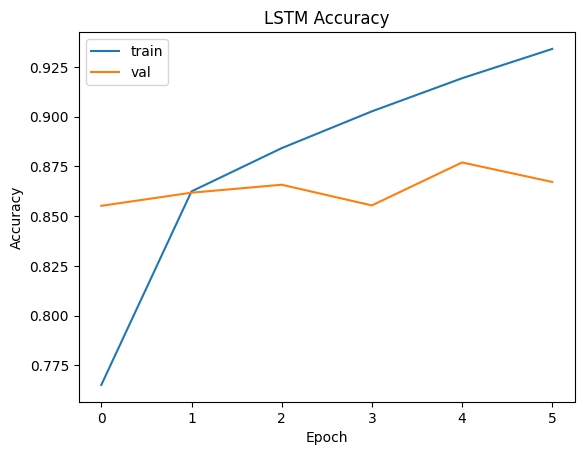

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step

RNN Classification Report:

              precision    recall  f1-score   support

         neg       0.51      0.39      0.44      2500
         pos       0.51      0.62      0.56      2500

    accuracy                           0.51      5000
   macro avg       0.51      0.51      0.50      5000
weighted avg       0.51      0.51      0.50      5000



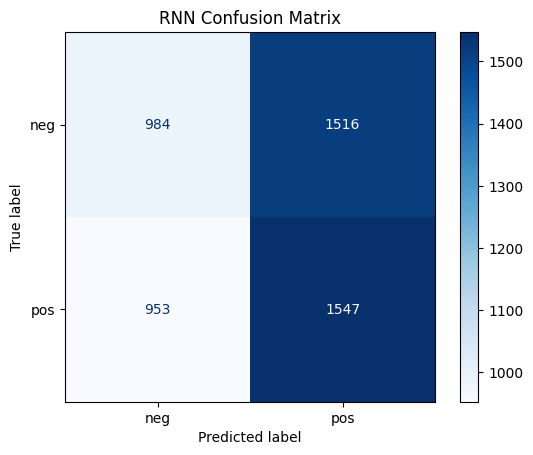

140/157 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_history(history_rnn, "RNN Accuracy")
plot_history(history_lstm, "LSTM Accuracy")

for name, model in [('RNN', rnn_model), ('LSTM', lstm_model)]:
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['neg', 'pos']))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['neg','pos']).plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
